# Predictive Analytics: Neural Network – Advanced v7

We performe a two-stage grid search based on v6. 

The first stage ("screening") trains eight targeted configurations for up to 20 epochs. The two best configurations are then reinitialized and trained for up to 100 epochs. Selection minimizes a normalized combination of global MAE (40%) and MAE for `trip_count > 20` (60%).

In [1]:
from copy import deepcopy
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from run_config import MODELS_DIR, PATHS

from helper_functions import (
    collect_predictions,
    compute_regression_metrics,
    get_torch_device,
    load_model_from_checkpoint,
    plot_regression_diagnostics,
    analyze_training_history
)

SPATIAL_UNIT = 'community_areas'
TIME_UNIT = '1h'
DATASET_STEM = f'GOLD_{TIME_UNIT.upper()}_DEMAND_{SPATIAL_UNIT.upper()}'
MODEL_TAG = f'{SPATIAL_UNIT}_{TIME_UNIT}'
TRAINING_DATA_PATH = PATHS.train_test_dir / f'{DATASET_STEM}_TRAIN.parquet'
VAL_DATA_PATH = PATHS.train_test_dir / f'{DATASET_STEM}_VAL.parquet'
MODEL_PATH = MODELS_DIR
MODEL_PATH.mkdir(parents=True, exist_ok=True)
V5_CHECKPOINT_PATH = MODEL_PATH / f'advanced_baseline_v5_NN_best_model.pt'

TARGET_COL = 'trip_count'
COMMUNITY_COL = 'community_area'
HIGH_DEMAND_THRESHOLD = 20
GLOBAL_MAE_WEIGHT = 0.4
HIGH_DEMAND_MAE_WEIGHT = 0.6
BATCH_SIZE = 1024
SEED = 42

EXCLUDE_COLS = {
    TARGET_COL, 'datetime_hour', 'date', '_split_bucket',
    'month', 'weekday', 'hour', 'most_common_payment_type',
    'trip_seconds_sum', 'trip_seconds_mean', 'trip_seconds_min', 'trip_seconds_max',
    'trip_miles_sum', 'trip_miles_mean', 'trip_miles_min', 'trip_miles_max',
    'fare_sum', 'fare_mean', 'fare_min', 'fare_max',
    'tips_sum', 'tips_mean', 'tips_min', 'tips_max',
    'tolls_sum', 'tolls_mean', 'tolls_min', 'tolls_max',
    'extras_sum', 'extras_mean', 'extras_min', 'extras_max',
    'trip_total_sum', 'trip_total_mean', 'trip_total_min', 'trip_total_max',
}

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = get_torch_device()
print('Using device:', device)

Using device: mps


## Data preparation
The mapping and scaler are fitted on training data only. Community IDs are kept separate from continuous inputs.

In [2]:
train_df = pl.read_parquet(TRAINING_DATA_PATH)
val_df = pl.read_parquet(VAL_DATA_PATH)
numeric_feature_cols = [c for c in train_df.columns if c not in EXCLUDE_COLS and c != COMMUNITY_COL]

community_values = sorted(train_df[COMMUNITY_COL].unique().to_list())
community_to_idx = {value: idx + 1 for idx, value in enumerate(community_values)}
num_communities = len(community_to_idx) + 1
community_train_idx = np.array([community_to_idx.get(v, 0) for v in train_df[COMMUNITY_COL]], dtype=np.int64)
community_val_idx = np.array([community_to_idx.get(v, 0) for v in val_df[COMMUNITY_COL]], dtype=np.int64)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df.select(numeric_feature_cols).to_numpy()).astype('float32')
X_val_scaled = scaler.transform(val_df.select(numeric_feature_cols).to_numpy()).astype('float32')
y_train_original = train_df[TARGET_COL].to_numpy().astype('float32')
y_val_original = val_df[TARGET_COL].to_numpy().astype('float32')
y_train_log = np.log1p(y_train_original).reshape(-1, 1).astype('float32')
y_val_log = np.log1p(y_val_original).reshape(-1, 1).astype('float32')

X_train_tensor = torch.tensor(X_train_scaled)
X_val_tensor = torch.tensor(X_val_scaled)
community_train_tensor = torch.tensor(community_train_idx, dtype=torch.long)
community_val_tensor = torch.tensor(community_val_idx, dtype=torch.long)
y_train_tensor = torch.tensor(y_train_log)
y_val_tensor = torch.tensor(y_val_log)
val_dataset = TensorDataset(X_val_tensor, community_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
numeric_input_dim = X_train_tensor.shape[1]
print(f'{numeric_input_dim=}, {num_communities=}, train={len(y_train_tensor):,}, val={len(y_val_tensor):,}')

numeric_input_dim=22, num_communities=78, train=627,181, val=134,043


## Configurable model and training functions

In [3]:
class TaxiDemandAdvancedNN(nn.Module):
    def __init__(self, numeric_input_dim, num_communities, embedding_dim=8, hidden_dims=(64, 32), dropout=0.0):
        super().__init__()
        self.community_embedding = nn.Embedding(num_communities, embedding_dim, padding_idx=0)
        layers = []
        in_features = numeric_input_dim + embedding_dim
        for hidden_dim in hidden_dims:
            layers.extend([nn.Linear(in_features, hidden_dim), nn.ReLU()])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden_dim
        layers.append(nn.Linear(in_features, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x_numeric, community_idx):
        embedding = self.community_embedding(community_idx)
        return self.network(torch.cat([x_numeric, embedding], dim=1))

def make_sample_weights(y, peak_weight):
    weights = np.ones_like(y, dtype=np.float32)
    weights[(y > 0) & (y <= 2)] = 1.2
    weights[(y > 2) & (y <= 10)] = 1.5
    weights[(y > 10) & (y <= HIGH_DEMAND_THRESHOLD)] = 3.0
    weights[y > HIGH_DEMAND_THRESHOLD] = peak_weight
    return weights

def make_train_loader(peak_weight, seed=SEED):
    weights = torch.tensor(make_sample_weights(y_train_original, peak_weight))
    dataset = TensorDataset(X_train_tensor, community_train_tensor, y_train_tensor, weights)
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)

def make_criterion(config):
    if config['loss'] == 'l1':
        return nn.L1Loss(reduction='none')
    if config['loss'] == 'smooth_l1':
        return nn.SmoothL1Loss(beta=config.get('beta', 0.5), reduction='none')
    raise ValueError(f"Unknown loss: {config['loss']}")

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum = 0.0
    sample_count = 0
    for x, community, y, weights in loader:
        x, community, y, weights = x.to(device), community.to(device), y.to(device), weights.to(device)
        optimizer.zero_grad()
        prediction = model(x, community)
        individual_loss = criterion(prediction, y).reshape(-1)
        loss = (individual_loss * weights.reshape(-1)).mean()
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        sample_count += x.size(0)
    return loss_sum / sample_count

def evaluate_model(model, criterion):
    model.eval()
    log_loss_sum, sample_count = 0.0, 0
    true_parts, pred_parts = [], []
    with torch.inference_mode():
        for x, community, y in val_loader:
            x, community, y = x.to(device), community.to(device), y.to(device)
            prediction = model(x, community)
            log_loss_sum += criterion(prediction, y).mean().item() * x.size(0)
            sample_count += x.size(0)
            true_parts.append(torch.expm1(y).cpu().numpy().reshape(-1))
            pred_parts.append(torch.clamp(torch.expm1(prediction), min=0).cpu().numpy().reshape(-1))
    y_true = np.rint(np.concatenate(true_parts)).astype(np.int64)
    y_pred = np.concatenate(pred_parts)
    errors = np.abs(y_true - y_pred)
    high_mask = y_true > HIGH_DEMAND_THRESHOLD
    return {
        'val_log_loss': log_loss_sum / sample_count,
        'val_mae': float(errors.mean()),
        'val_rmse': float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        'high_demand_mae': float(errors[high_mask].mean()),
        'high_demand_median_ae': float(np.median(errors[high_mask])),
        'high_demand_rmse': float(np.sqrt(np.mean((y_true[high_mask] - y_pred[high_mask]) ** 2))),
    }

## Recalculate the v5 baseline with the exact same `>20` definition

In [4]:
if not V5_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f'Run v5 first; checkpoint missing: {V5_CHECKPOINT_PATH}')

v5_model, _ = load_model_from_checkpoint(TaxiDemandAdvancedNN, V5_CHECKPOINT_PATH, device=device)
v5_metrics = evaluate_model(v5_model, nn.L1Loss(reduction='none'))
BASELINE_VAL_MAE = v5_metrics['val_mae']
BASELINE_HIGH_DEMAND_MAE = v5_metrics['high_demand_mae']
print('v5 baseline:', v5_metrics)

v5 baseline: {'val_log_loss': 0.3204760549558351, 'val_mae': 2.344387404523432, 'val_rmse': 8.822313028254127, 'high_demand_mae': 21.077180535814822, 'high_demand_median_ae': 11.936126708984375, 'high_demand_rmse': 33.123045613657524}


## Targeted grid and two-stage search

In [5]:
GRID = [
    {'name': 'v6_reference',       'peak_weight': 5.0,  'loss': 'l1',        'hidden_dims': (64, 32),      'lr': 1e-3},
    {'name': 'weight_8',           'peak_weight': 8.0,  'loss': 'l1',        'hidden_dims': (64, 32),      'lr': 1e-3},
    {'name': 'weight_12',          'peak_weight': 12.0, 'loss': 'l1',        'hidden_dims': (64, 32),      'lr': 1e-3},
    {'name': 'smooth_weight_5',    'peak_weight': 5.0,  'loss': 'smooth_l1', 'beta': 0.5, 'hidden_dims': (64, 32), 'lr': 1e-3},
    {'name': 'smooth_weight_8',    'peak_weight': 8.0,  'loss': 'smooth_l1', 'beta': 0.5, 'hidden_dims': (64, 32), 'lr': 1e-3},
    {'name': 'wider_weight_5',     'peak_weight': 5.0,  'loss': 'l1',        'hidden_dims': (128, 64, 32), 'lr': 1e-3},
    {'name': 'wider_weight_8',     'peak_weight': 8.0,  'loss': 'l1',        'hidden_dims': (128, 64, 32), 'lr': 1e-3},
    {'name': 'lower_lr_weight_8',  'peak_weight': 8.0,  'loss': 'l1',        'hidden_dims': (64, 32),      'lr': 5e-4},
]

def run_configuration(config, max_epochs, patience, stage):
    set_seed()
    model_kwargs = {
        'numeric_input_dim': numeric_input_dim, 'num_communities': num_communities,
        'embedding_dim': 8, 'hidden_dims': tuple(config['hidden_dims']), 'dropout': 0.0,
    }
    model = TaxiDemandAdvancedNN(**model_kwargs).to(device)
    criterion = make_criterion(config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    train_loader = make_train_loader(config['peak_weight'])
    best_score, best_result, stale_epochs = float('inf'), None, 0
    checkpoint_path = MODEL_PATH / f"advanced_v7_{MODEL_TAG}_{stage}_{config['name']}.pt"
    history_path = MODEL_PATH / f"advanced_v7_{MODEL_TAG}_{stage}_{config['name']}_training_history.parquet"
    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        metrics = evaluate_model(model, criterion)
        score = (
            GLOBAL_MAE_WEIGHT * metrics['val_mae'] / BASELINE_VAL_MAE
            + HIGH_DEMAND_MAE_WEIGHT * metrics['high_demand_mae'] / BASELINE_HIGH_DEMAND_MAE
        )
        scheduler.step(metrics['val_mae'])
        history.append({
            'epoch': epoch, 'train_loss': train_loss, 'selection_score': score,
            'learning_rate': optimizer.param_groups[0]['lr'], **metrics,
        })
        if score < best_score:
            best_score, stale_epochs = score, 0
            best_result = {'config': config['name'], 'stage': stage, 'best_epoch': epoch, 'selection_score': score, 'train_loss': train_loss, **metrics}
            torch.save({
                **best_result, 'config_values': deepcopy(config), 'model_kwargs': model_kwargs,
                'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(), 'community_to_idx': community_to_idx,
                'numeric_feature_cols': numeric_feature_cols, 'target_transform': 'log1p',
                'high_demand_threshold': HIGH_DEMAND_THRESHOLD,
                'baseline_val_mae': BASELINE_VAL_MAE,
                'baseline_high_demand_mae': BASELINE_HIGH_DEMAND_MAE,
            }, checkpoint_path)
        else:
            stale_epochs += 1
        print(f"{stage} | {config['name']:<20} | {epoch:03d} | score={score:.4f} | MAE={metrics['val_mae']:.4f} | high={metrics['high_demand_mae']:.4f}")
        if stale_epochs >= patience:
            break
    history_df = pl.DataFrame(history)
    history_df.write_parquet(history_path)
    print(f"Saved training history: {history_path}")
    best_result['history_path'] = str(history_path)
    return best_result

SCREENING_EPOCHS = 20
SCREENING_PATIENCE = 7
screening_results = [run_configuration(c, SCREENING_EPOCHS, SCREENING_PATIENCE, 'screening') for c in GRID]
screening_df = pl.DataFrame(screening_results).sort('selection_score')
screening_df

screening | v6_reference         | 001 | score=1.3948 | MAE=3.1488 | high=30.1246
screening | v6_reference         | 002 | score=1.2670 | MAE=2.8833 | high=27.2265
screening | v6_reference         | 003 | score=1.2442 | MAE=2.8055 | high=26.8924
screening | v6_reference         | 004 | score=1.2461 | MAE=2.7757 | high=27.1370
screening | v6_reference         | 005 | score=1.1829 | MAE=2.6899 | high=25.4316
screening | v6_reference         | 006 | score=1.1371 | MAE=2.5908 | high=24.4163
screening | v6_reference         | 007 | score=1.0970 | MAE=2.5266 | high=23.3909
screening | v6_reference         | 008 | score=1.1324 | MAE=2.5725 | high=24.3593
screening | v6_reference         | 009 | score=1.0782 | MAE=2.4828 | high=22.9961
screening | v6_reference         | 010 | score=1.0865 | MAE=2.5045 | high=23.1567
screening | v6_reference         | 011 | score=1.1776 | MAE=2.6972 | high=25.1994
screening | v6_reference         | 012 | score=1.0560 | MAE=2.4421 | high=22.4581
screening | v6_r

config,stage,best_epoch,selection_score,train_loss,val_log_loss,val_mae,val_rmse,high_demand_mae,high_demand_median_ae,high_demand_rmse,history_path
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""wider_weight_5""","""screening""",17,0.973589,0.434535,0.295359,2.286728,8.720497,20.495003,11.279074,32.691774,"""/Users/lennartjekel/dev/git/Gr…"
"""wider_weight_8""","""screening""",7,1.005303,0.498103,0.305577,2.412518,8.873888,20.85513,11.675644,32.928082,"""/Users/lennartjekel/dev/git/Gr…"
"""v6_reference""","""screening""",20,1.013086,0.442678,0.299201,2.365874,8.953865,21.40809,11.849041,33.532249,"""/Users/lennartjekel/dev/git/Gr…"
"""smooth_weight_8""","""screening""",19,1.017254,0.242485,0.158719,2.401598,8.977528,21.340385,11.715226,33.597326,"""/Users/lennartjekel/dev/git/Gr…"
"""weight_8""","""screening""",19,1.021948,0.495392,0.30145,2.403962,9.091,21.491099,11.901167,33.964323,"""/Users/lennartjekel/dev/git/Gr…"
"""weight_12""","""screening""",20,1.023326,0.562076,0.306052,2.443611,9.022691,21.301884,11.811893,33.494008,"""/Users/lennartjekel/dev/git/Gr…"
"""smooth_weight_5""","""screening""",19,1.030899,0.22071,0.156733,2.401044,9.102994,21.823029,12.35663,34.201114,"""/Users/lennartjekel/dev/git/Gr…"
"""lower_lr_weight_8""","""screening""",18,1.039347,0.5032,0.307469,2.453217,9.20782,21.807112,12.171656,34.330646,"""/Users/lennartjekel/dev/git/Gr…"


In [6]:
FINAL_EPOCHS = 100
FINAL_PATIENCE = 15
TOP_K = 2
top_names = screening_df.head(TOP_K)['config'].to_list()
top_configs = [config for name in top_names for config in GRID if config['name'] == name]
final_results = [run_configuration(c, FINAL_EPOCHS, FINAL_PATIENCE, 'final') for c in top_configs]

baseline_row = {'config': 'v5_baseline', 'stage': 'baseline', 'best_epoch': None, 'selection_score': 1.0, 'train_loss': None, **v5_metrics}
comparison_df = pl.DataFrame([baseline_row, *final_results]).with_columns(
    (pl.col('val_mae') / BASELINE_VAL_MAE).alias('relative_val_mae'),
    (pl.col('high_demand_mae') / BASELINE_HIGH_DEMAND_MAE).alias('relative_high_demand_mae'),
    (pl.col('val_mae') < BASELINE_VAL_MAE).alias('beats_v5_overall'),
    (pl.col('high_demand_mae') < BASELINE_HIGH_DEMAND_MAE).alias('beats_v5_high_demand'),
).sort('selection_score')
comparison_df

final | wider_weight_5       | 001 | score=1.4042 | MAE=3.1104 | high=30.6849
final | wider_weight_5       | 002 | score=1.1725 | MAE=2.6770 | high=25.1426
final | wider_weight_5       | 003 | score=1.3963 | MAE=3.0121 | high=30.9980
final | wider_weight_5       | 004 | score=1.0939 | MAE=2.5293 | high=23.2664
final | wider_weight_5       | 005 | score=1.0842 | MAE=2.4804 | high=23.2195
final | wider_weight_5       | 006 | score=1.0557 | MAE=2.4452 | high=22.4282
final | wider_weight_5       | 007 | score=1.0372 | MAE=2.4177 | high=21.9444
final | wider_weight_5       | 008 | score=1.0536 | MAE=2.4388 | high=22.3943
final | wider_weight_5       | 009 | score=1.0616 | MAE=2.4613 | high=22.5390
final | wider_weight_5       | 010 | score=1.0266 | MAE=2.3890 | high=21.7426
final | wider_weight_5       | 011 | score=1.1215 | MAE=2.5853 | high=23.9013
final | wider_weight_5       | 012 | score=1.0250 | MAE=2.3936 | high=21.6591
final | wider_weight_5       | 013 | score=0.9965 | MAE=2.3316 |

config,stage,best_epoch,selection_score,train_loss,val_log_loss,val_mae,val_rmse,high_demand_mae,high_demand_median_ae,high_demand_rmse,history_path,relative_val_mae,relative_high_demand_mae,beats_v5_overall,beats_v5_high_demand
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,bool,bool
"""wider_weight_8""","""final""",91,0.899227,0.447041,0.290051,2.166337,7.998496,18.604337,10.412313,29.766211,"""/Users/lennartjekel/dev/git/Gr…",0.924052,0.882677,true,true
"""wider_weight_5""","""final""",74,0.911683,0.410801,0.288768,2.170485,8.120909,19.01703,10.737016,30.345678,"""/Users/lennartjekel/dev/git/Gr…",0.925822,0.902257,true,true
"""v5_baseline""","""baseline""",null,1.0,null,0.320476,2.344387,8.822313,21.077181,11.936127,33.123046,null,1.0,1.0,false,false


## Load and diagnose the winning final model

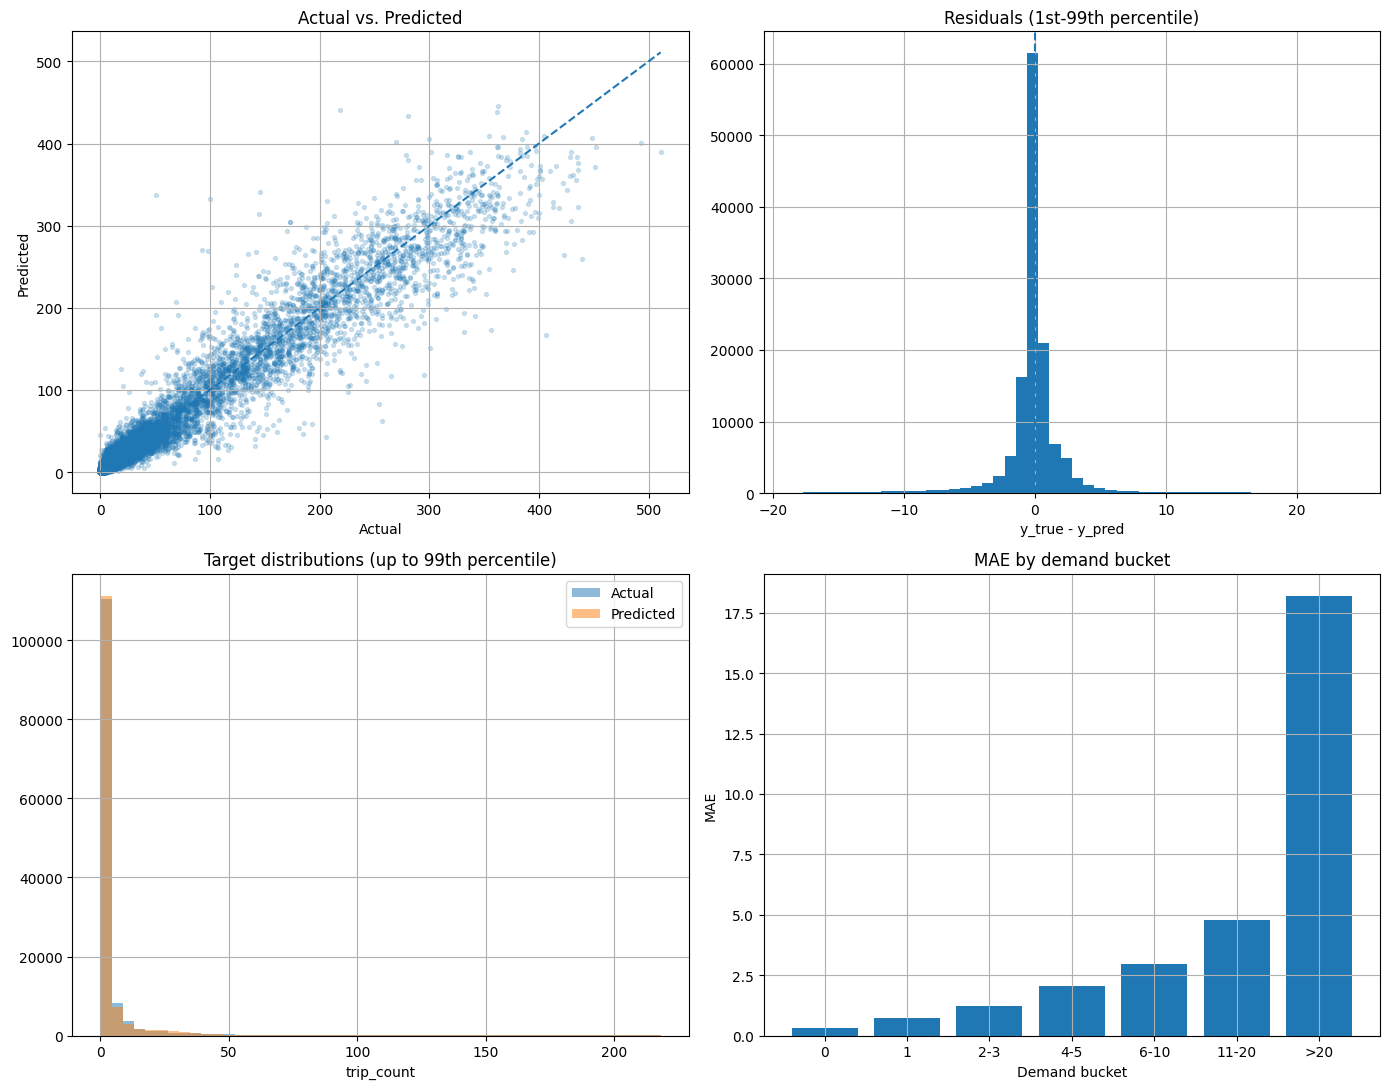

Winner: wider_weight_8
shape: (16, 2)
┌────────────────┬───────────┐
│ metric         ┆ value     │
│ ---            ┆ ---       │
│ str            ┆ f64       │
╞════════════════╪═══════════╡
│ n_samples      ┆ 134043.0  │
│ mae            ┆ 2.166337  │
│ mse            ┆ 63.975948 │
│ rmse           ┆ 7.998497  │
│ r2             ┆ 0.950421  │
│ …              ┆ …         │
│ nonzero_rmse   ┆ 10.691028 │
│ peak_threshold ┆ 27.999998 │
│ peak_share     ┆ 0.055878  │
│ peak_mae       ┆ 21.289602 │
│ peak_rmse      ┆ 32.539387 │
└────────────────┴───────────┘
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 59291  ┆ 0.297262  ┆ 0.0        ┆ 0            │
│ 1             ┆ 2

In [10]:
winner_name = pl.DataFrame(final_results).sort('selection_score')[0, 'config']
winner_path = MODEL_PATH / f'advanced_v7_{MODEL_TAG}_final_{winner_name}.pt'
winner_model, winner_checkpoint = load_model_from_checkpoint(TaxiDemandAdvancedNN, winner_path, device=device)
winner_eval_df = collect_predictions(winner_model, val_loader, device=device, embedding_input=True)
winner_metrics_df = compute_regression_metrics(winner_eval_df)
figure, winner_bucket_df = plot_regression_diagnostics(winner_eval_df)
plt.show()
print('Winner:', winner_name)
print(winner_metrics_df)
print(winner_bucket_df)

Winning architecture/configuration transferred to other datasets: {'name': 'wider_weight_8', 'peak_weight': 8.0, 'loss': 'l1', 'hidden_dims': (128, 64, 32), 'lr': 0.001}

=== Training v7 winner architecture: community_areas_4h ===
community_areas_4h | 001 | MAE=14.1441 | high=70.8142 | stale=0/15
community_areas_4h | 002 | MAE=11.6963 | high=61.9838 | stale=0/15
community_areas_4h | 003 | MAE=10.9530 | high=58.0462 | stale=0/15
community_areas_4h | 004 | MAE=10.1414 | high=53.2888 | stale=0/15
community_areas_4h | 005 | MAE=10.8035 | high=57.5956 | stale=1/15
community_areas_4h | 006 | MAE=9.5944 | high=50.8650 | stale=0/15
community_areas_4h | 007 | MAE=8.8084 | high=45.5631 | stale=0/15
community_areas_4h | 008 | MAE=8.7226 | high=45.3543 | stale=0/15
community_areas_4h | 009 | MAE=8.7209 | high=46.0660 | stale=0/15
community_areas_4h | 010 | MAE=8.5556 | high=45.3360 | stale=0/15
community_areas_4h | 011 | MAE=8.2299 | high=42.6256 | stale=0/15
community_areas_4h | 012 | MAE=9.3553 

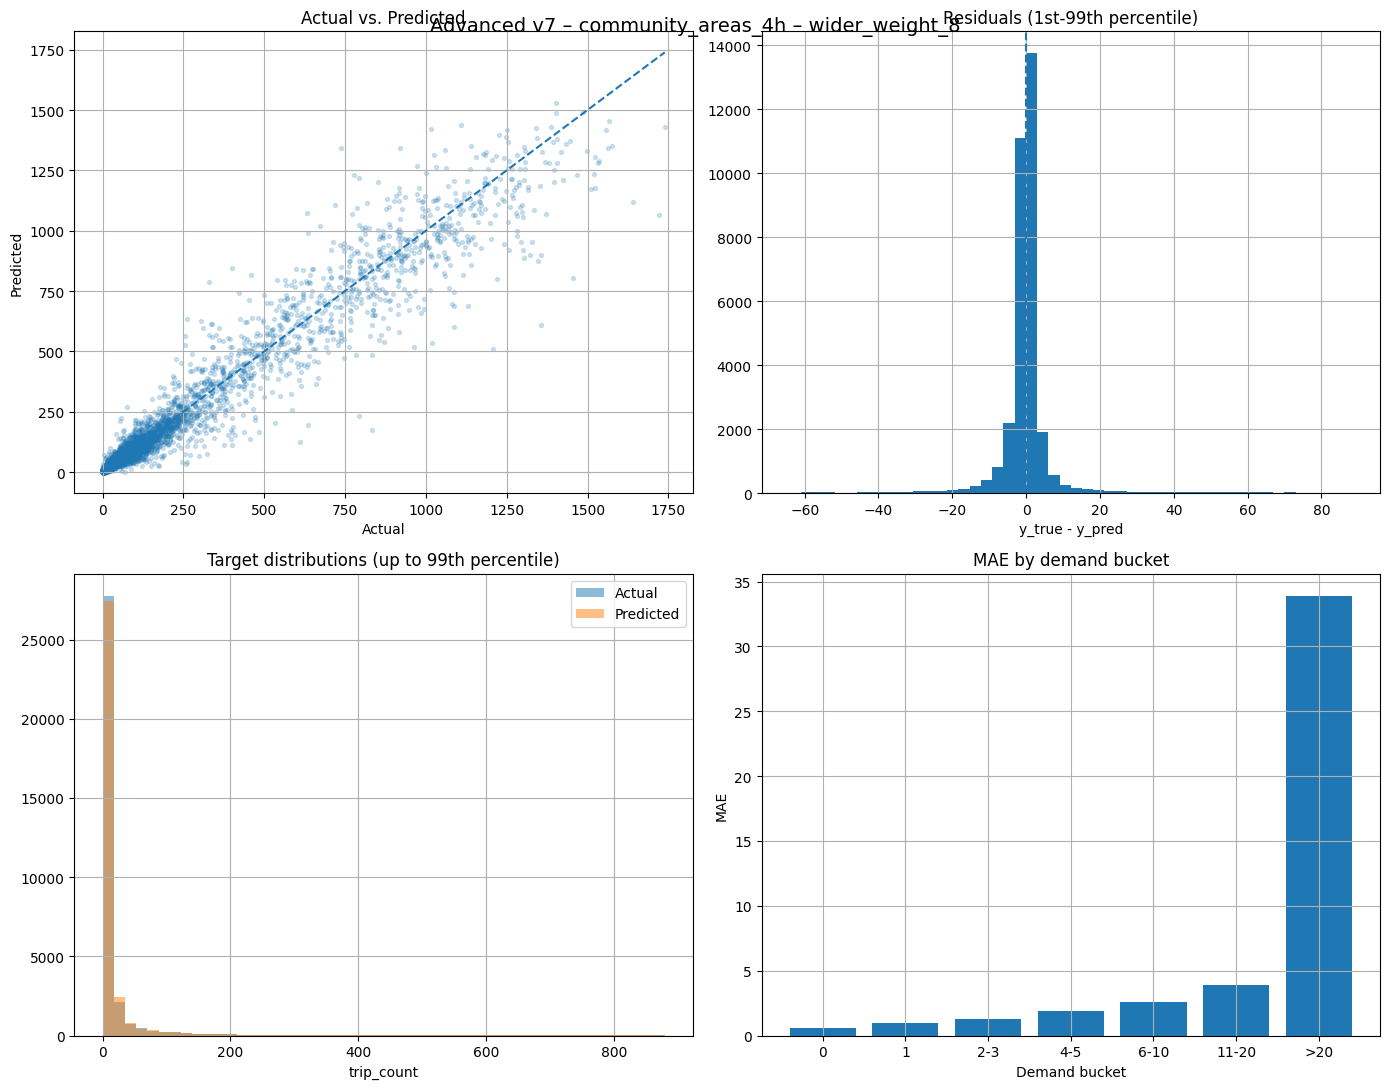

shape: (16, 2)
┌────────────────┬────────────┐
│ metric         ┆ value      │
│ ---            ┆ ---        │
│ str            ┆ f64        │
╞════════════════╪════════════╡
│ n_samples      ┆ 33572.0    │
│ mae            ┆ 6.851515   │
│ mse            ┆ 837.630859 │
│ rmse           ┆ 28.941853  │
│ r2             ┆ 0.957509   │
│ …              ┆ …          │
│ nonzero_rmse   ┆ 32.304207  │
│ peak_threshold ┆ 61.099606  │
│ peak_share     ┆ 0.080245   │
│ peak_mae       ┆ 60.418999  │
│ peak_rmse      ┆ 101.059494 │
└────────────────┴────────────┘
shape: (7, 5)
┌───────────────┬────────┬──────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae      ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---      ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32      ┆ f32        ┆ i64          │
╞═══════════════╪════════╪══════════╪════════════╪══════════════╡
│ 0             ┆ 6632   ┆ 0.560314 ┆ 0.0        ┆ 0            │
│ 1             ┆ 4650   ┆ 0.99

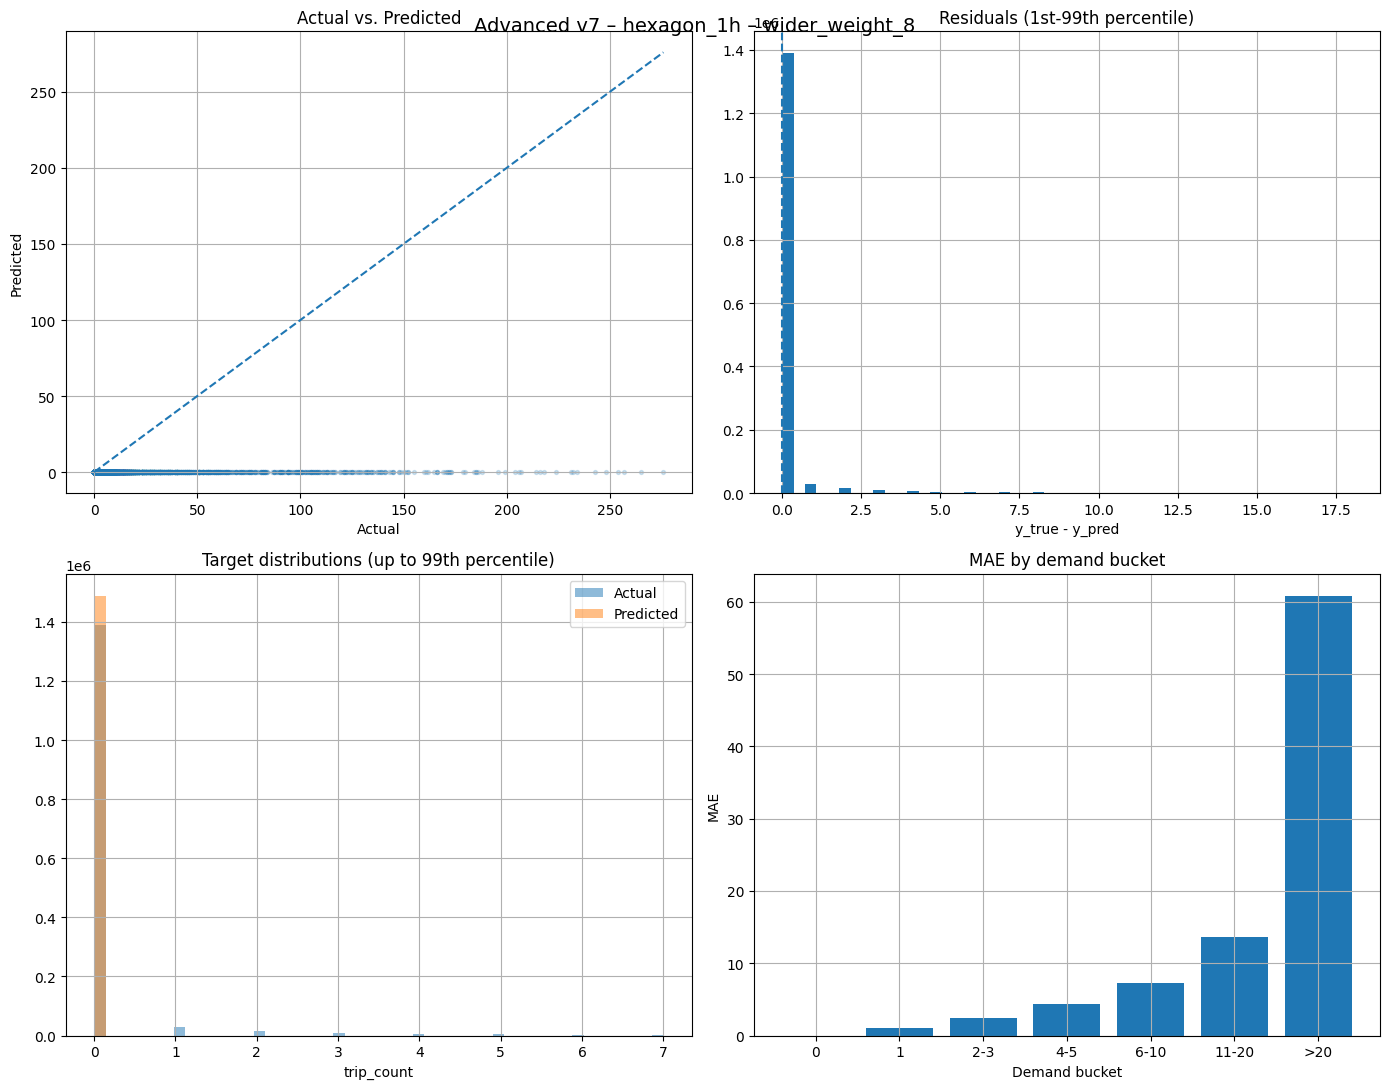

shape: (16, 2)
┌────────────────┬────────────┐
│ metric         ┆ value      │
│ ---            ┆ ---        │
│ str            ┆ f64        │
╞════════════════╪════════════╡
│ n_samples      ┆ 1.487826e6 │
│ mae            ┆ 0.790958   │
│ mse            ┆ 53.786568  │
│ rmse           ┆ 7.333932   │
│ r2             ┆ -0.011769  │
│ …              ┆ …          │
│ nonzero_rmse   ┆ 28.490412  │
│ peak_threshold ┆ 29.999998  │
│ peak_share     ┆ 0.006794   │
│ peak_mae       ┆ 74.427582  │
│ peak_rmse      ┆ 86.210327  │
└────────────────┴────────────┘
shape: (7, 5)
┌───────────────┬─────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows  ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---     ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32     ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪═════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 1389237 ┆ 0.0       ┆ 0.0        ┆ 0            │
│ 1             ┆ 2

In [ ]:
# Train the winning v7 architecture on all remaining temporal/spatial units.
TRANSFER_DATASET_CONFIGS = (
    {'spatial_unit': 'hexagon', 'spatial_col': 'h3_cell', 'time_unit': '1h'},
    {'spatial_unit': 'census_tracts', 'spatial_col': 'census_tract', 'time_unit': '1h'},
    {'spatial_unit': 'community_areas', 'spatial_col': 'community_area', 'time_unit': '1h'},
    {'spatial_unit': 'hexagon', 'spatial_col': 'h3_cell', 'time_unit': '2h'},
    {'spatial_unit': 'census_tracts', 'spatial_col': 'census_tract', 'time_unit': '2h'},
    {'spatial_unit': 'community_areas', 'spatial_col': 'community_area', 'time_unit': '2h'},
    {'spatial_unit': 'hexagon', 'spatial_col': 'h3_cell', 'time_unit': '4h'},
    {'spatial_unit': 'census_tracts', 'spatial_col': 'census_tract', 'time_unit': '4h'},
)

winner_config = deepcopy(next(config for config in GRID if config['name'] == winner_name))
print('Winning architecture/configuration transferred to other datasets:', winner_config)

def evaluate_transfer_model(model, loader, criterion):
    model.eval()
    log_loss_sum, sample_count = 0.0, 0
    true_parts, pred_parts = [], []
    with torch.inference_mode():
        for x, spatial_idx, y in loader:
            x, spatial_idx, y = x.to(device), spatial_idx.to(device), y.to(device)
            prediction = model(x, spatial_idx)
            log_loss_sum += criterion(prediction, y).mean().item() * x.size(0)
            sample_count += x.size(0)
            true_parts.append(torch.expm1(y).cpu().numpy().reshape(-1))
            pred_parts.append(torch.clamp(torch.expm1(prediction), min=0).cpu().numpy().reshape(-1))
    y_true = np.rint(np.concatenate(true_parts)).astype(np.int64)
    y_pred = np.concatenate(pred_parts)
    errors = np.abs(y_true - y_pred)
    high_mask = y_true > HIGH_DEMAND_THRESHOLD
    return {
        'val_log_loss': log_loss_sum / sample_count,
        'val_mae': float(errors.mean()),
        'val_rmse': float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        'high_demand_mae': float(errors[high_mask].mean()) if high_mask.any() else float('nan'),
        'high_demand_median_ae': float(np.median(errors[high_mask])) if high_mask.any() else float('nan'),
        'high_demand_rmse': float(np.sqrt(np.mean((y_true[high_mask] - y_pred[high_mask]) ** 2))) if high_mask.any() else float('nan'),
    }

def train_winner_on_dataset(dataset_config):
    set_seed()
    spatial_unit = dataset_config['spatial_unit']
    spatial_col = dataset_config['spatial_col']
    time_unit = dataset_config['time_unit']
    dataset_stem = f'GOLD_{time_unit.upper()}_DEMAND_{spatial_unit.upper()}'
    model_tag = f'{spatial_unit}_{time_unit}'
    train_path = PATHS.train_test_dir / f'{dataset_stem}_TRAIN.parquet'
    val_path = PATHS.train_test_dir / f'{dataset_stem}_VAL.parquet'
    print(f'\n=== Training v7 winner architecture: {model_tag} ===')

    dataset_train_df = pl.read_parquet(train_path)
    dataset_val_df = pl.read_parquet(val_path)
    numeric_cols = [
        col for col in dataset_train_df.columns
        if col not in EXCLUDE_COLS and col != spatial_col
    ]
    spatial_values = sorted(dataset_train_df[spatial_col].unique().to_list())
    spatial_to_idx = {value: idx + 1 for idx, value in enumerate(spatial_values)}
    train_spatial_idx = np.array(
        [spatial_to_idx.get(value, 0) for value in dataset_train_df[spatial_col]], dtype=np.int64
    )
    val_spatial_idx = np.array(
        [spatial_to_idx.get(value, 0) for value in dataset_val_df[spatial_col]], dtype=np.int64
    )

    dataset_scaler = StandardScaler()
    x_train = dataset_scaler.fit_transform(
        dataset_train_df.select(numeric_cols).to_numpy()
    ).astype('float32')
    x_val = dataset_scaler.transform(
        dataset_val_df.select(numeric_cols).to_numpy()
    ).astype('float32')
    y_train_original_local = dataset_train_df[TARGET_COL].to_numpy().astype('float32')
    y_val_original_local = dataset_val_df[TARGET_COL].to_numpy().astype('float32')
    y_train = np.log1p(y_train_original_local).reshape(-1, 1).astype('float32')
    y_val = np.log1p(y_val_original_local).reshape(-1, 1).astype('float32')

    x_train_t, x_val_t = torch.tensor(x_train), torch.tensor(x_val)
    spatial_train_t = torch.tensor(train_spatial_idx, dtype=torch.long)
    spatial_val_t = torch.tensor(val_spatial_idx, dtype=torch.long)
    y_train_t, y_val_t = torch.tensor(y_train), torch.tensor(y_val)
    weights_t = torch.tensor(make_sample_weights(y_train_original_local, winner_config['peak_weight']))
    generator = torch.Generator().manual_seed(SEED)
    dataset_train_loader = DataLoader(
        TensorDataset(x_train_t, spatial_train_t, y_train_t, weights_t),
        batch_size=BATCH_SIZE, shuffle=True, generator=generator,
    )
    dataset_val_loader = DataLoader(
        TensorDataset(x_val_t, spatial_val_t, y_val_t),
        batch_size=BATCH_SIZE, shuffle=False,
    )

    model_kwargs = {
        'numeric_input_dim': x_train_t.shape[1],
        'num_communities': len(spatial_to_idx) + 1,
        'embedding_dim': winner_checkpoint['model_kwargs'].get('embedding_dim', 8),
        'hidden_dims': tuple(winner_config['hidden_dims']),
        'dropout': winner_checkpoint['model_kwargs'].get('dropout', 0.0),
    }
    model = TaxiDemandAdvancedNN(**model_kwargs).to(device)
    criterion = make_criterion(winner_config)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=winner_config['lr'], weight_decay=1e-5
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    checkpoint_path = MODEL_PATH / f'advanced_v7_{model_tag}_winner_architecture_{winner_name}.pt'
    history_path = MODEL_PATH / f'advanced_v7_{model_tag}_winner_architecture_{winner_name}_training_history.parquet'
    best_val_mae, stale_epochs, history = float('inf'), 0, []

    for epoch in range(1, FINAL_EPOCHS + 1):
        train_loss = train_one_epoch(model, dataset_train_loader, criterion, optimizer)
        metrics = evaluate_transfer_model(model, dataset_val_loader, criterion)
        scheduler.step(metrics['val_mae'])
        row = {
            'epoch': epoch, 'train_loss': train_loss,
            'learning_rate': optimizer.param_groups[0]['lr'], **metrics,
        }
        history.append(row)
        if metrics['val_mae'] < best_val_mae:
            best_val_mae, stale_epochs = metrics['val_mae'], 0
            torch.save({
                **row, 'best_epoch': epoch, 'selection_metric': 'val_mae',
                'source_grid_model_tag': MODEL_TAG, 'source_winner': winner_name,
                'config_values': deepcopy(winner_config), 'model_kwargs': model_kwargs,
                'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(), 'spatial_unit': spatial_unit,
                'spatial_col': spatial_col, 'spatial_to_idx': spatial_to_idx,
                'numeric_feature_cols': numeric_cols, 'target_transform': 'log1p',
                'scaler_mean': dataset_scaler.mean_, 'scaler_scale': dataset_scaler.scale_,
                'high_demand_threshold': HIGH_DEMAND_THRESHOLD,
            }, checkpoint_path)
        else:
            stale_epochs += 1
        print(
            f'{model_tag} | {epoch:03d} | MAE={metrics["val_mae"]:.4f} | '
            f'high={metrics["high_demand_mae"]:.4f} | stale={stale_epochs}/{FINAL_PATIENCE}'
        )
        if stale_epochs >= FINAL_PATIENCE:
            break

    history_df = pl.DataFrame(history)
    history_df.write_parquet(history_path)
    best_model, best_checkpoint = load_model_from_checkpoint(
        TaxiDemandAdvancedNN, checkpoint_path, device=device
    )
    evaluation_df = collect_predictions(
        best_model, dataset_val_loader, device=device, embedding_input=True
    )
    metrics_df = compute_regression_metrics(evaluation_df)
    figure, bucket_df = plot_regression_diagnostics(evaluation_df)
    figure.suptitle(f'Advanced v7 – {model_tag} – {winner_name}', fontsize=14)
    plt.show()
    print(metrics_df)
    print(bucket_df)
    return {
        'model_tag': model_tag, 'model_path': checkpoint_path,
        'history_path': history_path, 'history_df': history_df,
        'metrics': metrics_df, 'bucket_metrics': bucket_df,
        'best_epoch': best_checkpoint['best_epoch'],
    }

transfer_results = {}
transfer_history_dfs = {}
for dataset_config in TRANSFER_DATASET_CONFIGS:
    result = train_winner_on_dataset(dataset_config)
    transfer_results[result['model_tag']] = result
    transfer_history_dfs[result['model_tag']] = result['history_df']

original_history_path = (
    MODEL_PATH / f'advanced_v7_{MODEL_TAG}_final_{winner_name}_training_history.parquet'
)
all_v7_results = {
    MODEL_TAG: {
        'model_tag': MODEL_TAG, 'model_path': winner_path,
        'history_path': original_history_path,
        'history_df': pl.read_parquet(original_history_path),
        'metrics': winner_metrics_df, 'bucket_metrics': winner_bucket_df,
    },
    **transfer_results,
}
all_v7_history_dfs = {
    model_tag: result['history_df'] for model_tag, result in all_v7_results.items()
}
print('Completed v7 models:', list(all_v7_results))


Training history: /Users/lennartjekel/dev/git/Group-3-AAA/models/full/advanced_v7_community_areas_1h_final_wider_weight_8_training_history.parquet
Best metric: selection_score (minimum)
shape: (17, 2)
┌───────────────────────────────┬───────────┐
│ metric                        ┆ value     │
│ ---                           ┆ ---       │
│ str                           ┆ f64       │
╞═══════════════════════════════╪═══════════╡
│ epochs_trained                ┆ 100.0     │
│ best_epoch                    ┆ 91.0      │
│ best_selection_score          ┆ 0.899227  │
│ train_loss_at_best_epoch      ┆ 0.447041  │
│ final_train_loss              ┆ 0.446769  │
│ …                             ┆ …         │
│ final_high_demand_mae         ┆ 18.599718 │
│ selection_score_at_best_epoch ┆ 0.899227  │
│ final_selection_score         ┆ 0.899452  │
│ learning_rate_at_best_epoch   ┆ 0.000016  │
│ final_learning_rate           ┆ 0.000008  │
└───────────────────────────────┴───────────┘


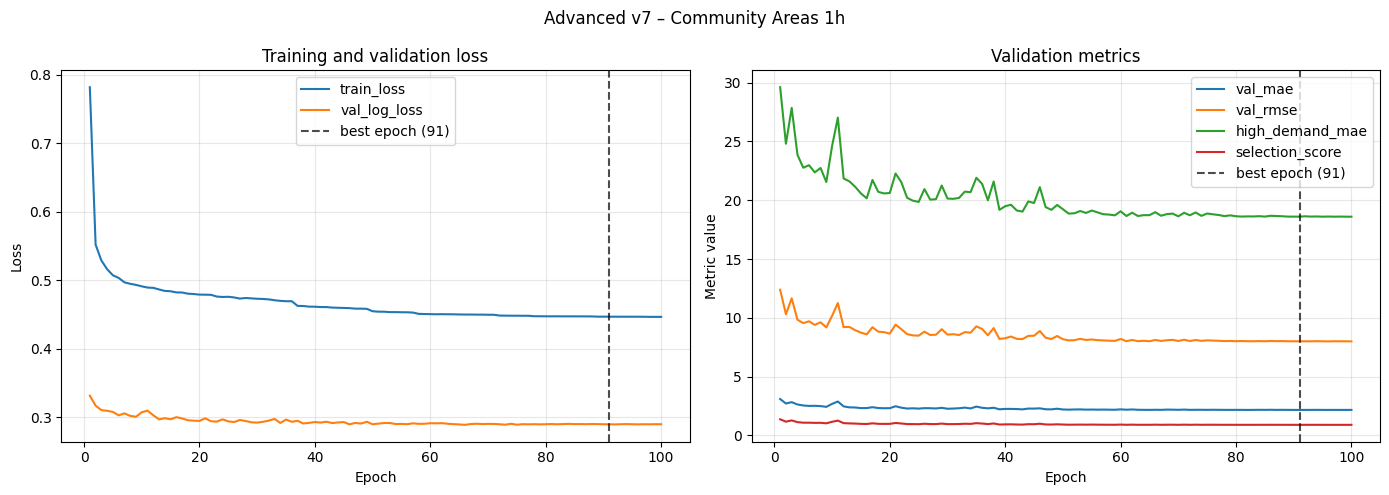

In [4]:
analysis = analyze_training_history(
    MODEL_PATH / "advanced_v7_community_areas_1h_final_wider_weight_8_training_history.parquet",
    title="Advanced v7 – Community Areas 1h",
)